In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

%cd /g/data/w42/dr6273/work/wind_drought/
import utils

/g/data/w42/dr6273/work/wind_drought


In [95]:
import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [96]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### BARRA-R2 wind speed data for NEM-2030 MJJ

In [97]:
obs_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_nem-2030.nc'

In [5]:
ds_obs = xr.open_dataset(obs_infile)
ds_obs = ds_obs.compute()


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: /g/data/w42/dr6273/work/unseen_venv/bin/python3 -m pip install --upgrade pip


In [112]:
ds_obs

<xarray.Dataset> Size: 68kB
Dimensions:  (time: 4232)
Coordinates:
  * time     (time) datetime64[ns] 34kB 1980-05-01T12:00:00 ... 2025-07-31T12...
Data variables:
    sfcWind  (time) float64 34kB 3.886 4.319 4.307 4.119 ... 2.612 3.348 3.062
Attributes: (12/61)
    CDI:                       Climate Data Interface version 2.4.3 (https://...
    Conventions:               CF-1.10, ACDD-1.3
    source:                    Data from Met Office Unified Model (UM, versio...
    institution:               Bureau of Meteorology
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        88.48
    geospatial_lon_max:        207.39
    geospatial_lon_units:      degrees_east
    history:                   Mon May 11 11:26:42 2026: cdo mergetime sfcWin...
    CDO:                       Climate Data Operators version 2.4.3 (https://...

In [7]:
sfcWind_obs_data = ds_obs['sfcWind'].values

In [8]:
pctl10_obs = np.percentile(sfcWind_obs_data, 10)

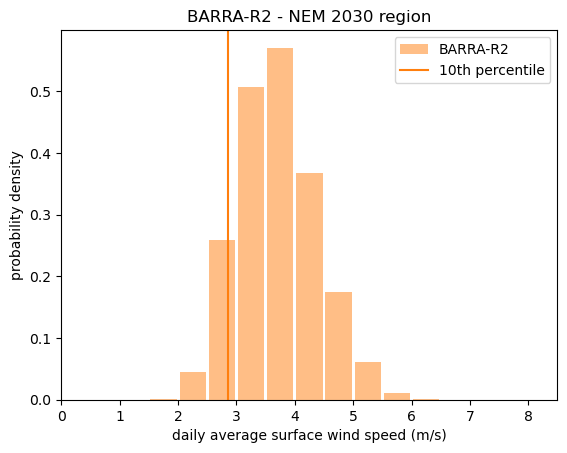

In [9]:
bins = np.arange(0, 9.5, 0.5)
plt.hist(sfcWind_obs_data, bins=bins, density=True, rwidth=0.9, label='BARRA-R2', color='tab:orange', alpha=0.5)
plt.axvline(pctl10_obs, color='tab:orange', label='10th percentile')
plt.xlabel('daily average surface wind speed (m/s)')
plt.ylabel('probability density')
plt.title('BARRA-R2 - NEM 2030 region')
plt.xlim(0, 8.5)
plt.legend()
plt.show()

### Calculate annual maximum wind drought duration (WDDx)

In [10]:
wddx_obs = utils.calc_wddx_obs(ds_obs, pctl10_obs)

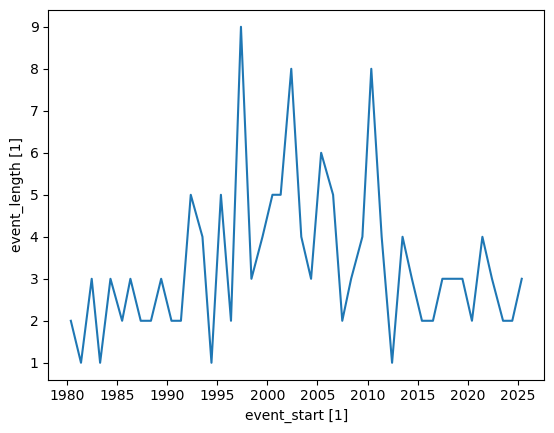

In [11]:
wddx_obs["event_length"].plot()

In [12]:
years = wddx_obs['event_start'].dt.year.values
df = pd.DataFrame(index=years)
df['WDDx'] = wddx_obs['event_length'].values
df['start_date'] = wddx_obs['event_start'].dt.strftime('%Y-%m-%d')
df.sort_values(['WDDx'], ascending=False).head(n=10)

,WDDx,start_date
1997,9.0,1997-05-16
2002,8.0,2002-05-22
2010,8.0,2010-05-14
2005,6.0,2005-05-14
1992,5.0,1992-05-14
2001,5.0,2001-05-01
2000,5.0,2000-07-06
2006,5.0,2006-07-23
1995,5.0,1995-05-17
1999,4.0,1999-07-09


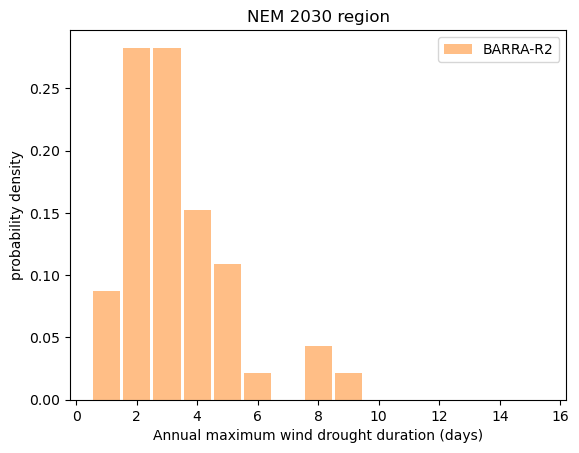

In [13]:
bins = np.arange(0.5, 16.5, 1)

plt.hist(
    wddx_obs['event_length'].values,
    bins=bins,
    density=True,
    rwidth=0.9,
    label='BARRA-R2',
    color='tab:orange',
    alpha=0.5
)
plt.xlabel('Annual maximum wind drought duration (days)')
plt.ylabel('probability density')
plt.title('NEM 2030 region')
plt.legend()
plt.show()

### Gridded data

#### tasmax

In [14]:
# tasmax_path = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/day/tasmax/latest/'

We want anomalies, so compute the climatology for MJJ

MSLP (psl)

In [15]:
psl_path = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/day/psl/latest/'

Wind speed (sfcWind)

In [16]:
sfcWind_path = '/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/day/sfcWind/latest/'

### Composite plots

10 longest droughts

In [17]:
top10 = df.sort_values(['WDDx'], ascending=False).head(n=10)

In [18]:
top10

,WDDx,start_date
1997,9.0,1997-05-16
2002,8.0,2002-05-22
2010,8.0,2010-05-14
2005,6.0,2005-05-14
1992,5.0,1992-05-14
2001,5.0,2001-05-01
2000,5.0,2000-07-06
2006,5.0,2006-07-23
1995,5.0,1995-05-17
1999,4.0,1999-07-09


In [180]:
def sfcWind_slice(da, event_start, event_duration, days_before, days_after):
    """ Return da around event """
    time_slice = pd.date_range(
        pd.to_datetime(event_start) - pd.DateOffset(days=days_before),
        pd.to_datetime(event_start) + pd.DateOffset(days=event_duration + days_after)
    ) + pd.Timedelta(hours=12)
    return da.sel(time=time_slice)

In [233]:
def plot_ts(ax, da, thresh):
    """ Plot wind drought event time series """
    da.plot(marker='o')
    ax.axhline(thresh, c="k")
    ax.fill_between(x=da.time, y1=da, y2=thresh, where=da<thresh, interpolate=True, alpha=0.5)

In [19]:
def barra_var_for_month(var_name, var_path, year, month):
    """
    BARRA-R2 data for a given month

    var_name: str, name of variable
    var_path: str, path to variable
    year: str, year to open
    month: str, month to open
    """
    var_fname = var_name + '_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_day_'
    return xr.open_mfdataset(
        var_path + var_fname + year + month + '-' + year + month + '.nc'
    )[var_name]

In [249]:
def barra_var_for_event(event_start, event_duration, var_name, var_path):
    """
    BARRA-R2 data during an event

    event_start: str, start day of event in format yyyy-mm-dd
    event_duration: int or float, duration of event
    var_name: str, name of variable
    var_path: str, path to variable
    """
    year, month, day = event_start.split('-')
    next_month = (int('12')+1) % 12
    next_month = f"{next_month:02}"

    # Data for start month, and next month, in case event lasts into next month
    var_month = barra_var_for_month(var_name, var_path, year, month)
    var_month_next = barra_var_for_month(var_name, var_path, year, next_month)
    var_month = xr.concat([var_month, var_month_next], dim="time")

    event_days = pd.date_range(
        pd.to_datetime(event_start), pd.to_datetime(event_start) + pd.DateOffset(days=duration + 1)
    ) + pd.Timedelta(hours=12)
    
    # return var_month.where(
    #     (var_month.time.dt.day >= int(day)) & (var_month.time.dt.day < int(day) + int(event_duration) + 2),
    #     drop=True
    # )
    return var_month.sel(time=event_days)

In [260]:
def plot_event(event_id):
    """
    Plot maps of events
    """
    # Event stats
    duration, start = top10.iloc[event_id]
    wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 2, 2)
    psl_event = barra_var_for_event(start, duration, 'psl', psl_path)
    sfcWind_event = barra_var_for_event(start, duration, 'sfcWind', sfcWind_path)

    fig, ax = plt.subplots(3, 4, figsize=(7,6), subplot_kw={'projection': ccrs.PlateCarree()})
    axs_flat = ax.flatten()

    # time series
    # axs_flat[0] = fig.add_subplot(3, 5, 1)
    # plot_ts(axs_flat[0], wind_ts, pctl10_obs)

    # Composite mean
    # axs_flat[0] = fig.add_subplot(3, 4, 1, projection=ccrs.PlateCarree())
    sfcWind_event.isel(time=range(int(duration))).mean('time').plot.contourf(ax=axs_flat[0], alpha=1, levels=np.arange(0, 22, 3), add_colorbar=False)
    print(sfcWind_event.isel(time=range(int(duration))).mean('time').max().values)
    (psl_event / 100).isel(time=range(int(duration))).mean('time').plot.contour(ax=axs_flat[0], colors="k")
    axs_flat[0].set_title('Composite mean')
    
    # Individual days
    for i in range(int(duration) + 2):
        # axs_flat[i+1] = fig.add_subplot(3, 4, i+2, projection=ccrs.PlateCarree())
        sfcWind_event.isel(time=i).plot.contourf(ax=axs_flat[i+1], alpha=1, levels=np.arange(0, 22, 3), add_colorbar=False)
        print(sfcWind_event.isel(time=i).max().values)
        CS = (psl_event / 100).isel(time=i).plot.contour(ax=axs_flat[i+1], colors="k")
        if i < duration:
            axs_flat[i+1].set_title('Day ' + str(i+1))#psl_event.isel(time=i).time.values)
        else:
            axs_flat[i+1].set_title('Break day ' + str(i+1))
        # axs_flat[i].clabel(CS, inline=True, fontsize=10)
    
    for a in axs_flat[:int(duration)+3]:
        a.coastlines()
        a.set_extent([90, 180, 0, -49])
        a.set_xlabel("")
        a.set_ylabel("")

    for a in axs_flat[int(duration)+3:]:
        a.set_axis_off()
    
    plt.tight_layout()

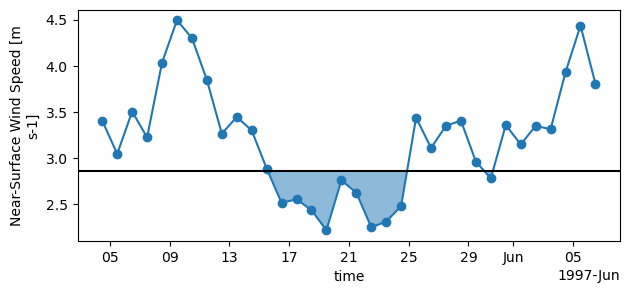

In [261]:
fig, ax = plt.subplots(1,1, figsize=(7,3))
duration, start = top10.iloc[0]
wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 12, 12)
plot_ts(ax, wind_ts, pctl10_obs)

15.879774305555555
19.185546875
18.47265625
19.1328125
19.30078125
18.767578125
18.302734375
18.517578125
20.904296875
19.97265625
20.5625
20.6640625


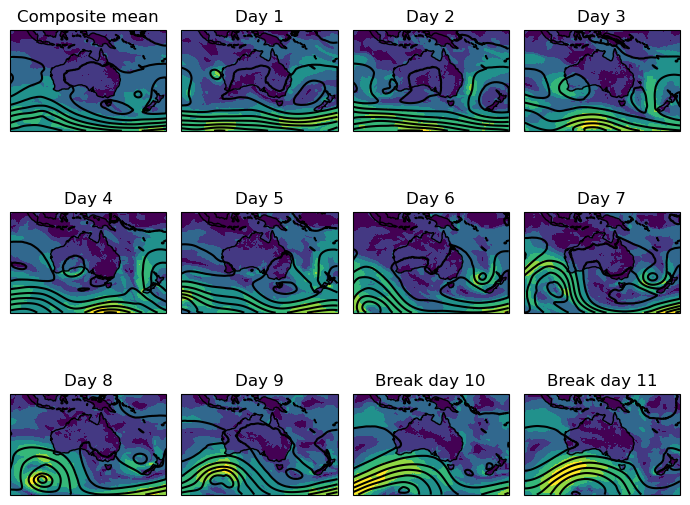

In [262]:
plot_event(0)

z500, 300 meridional wind, weather objects, SWTs, blocking indices
solar: radiation

SWT: x: event ID; y: day of event.. http://www.weathermanbarnes.com/forecast_eIFS.html

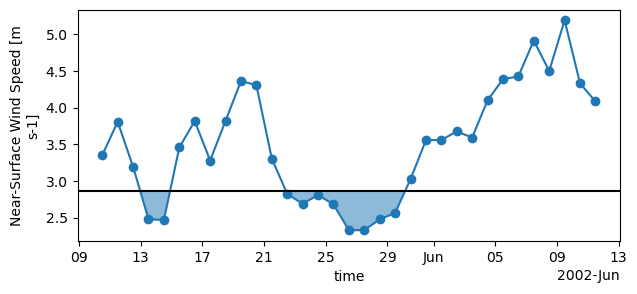

In [263]:
fig, ax = plt.subplots(1,1, figsize=(7,3))
duration, start = top10.iloc[1]
wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 12, 12)
plot_ts(ax, wind_ts, pctl10_obs)

15.383544921875
20.763671875
19.830078125
17.494140625
19.994140625
20.318359375
19.974609375
18.45703125
17.166015625
15.142578125
16.529296875


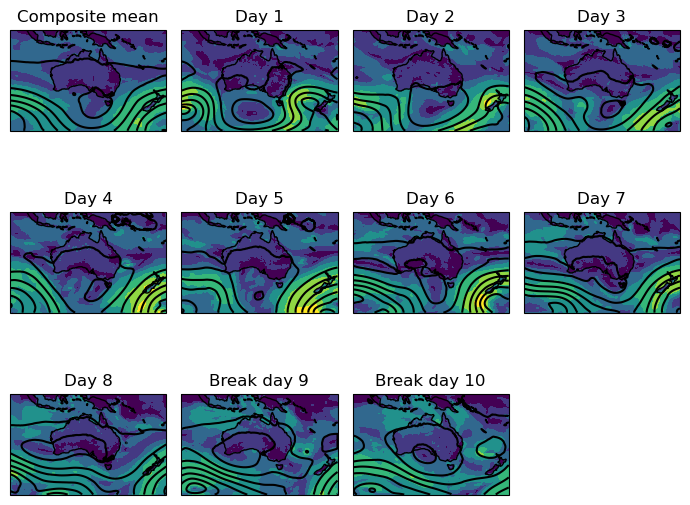

In [264]:
plot_event(1)

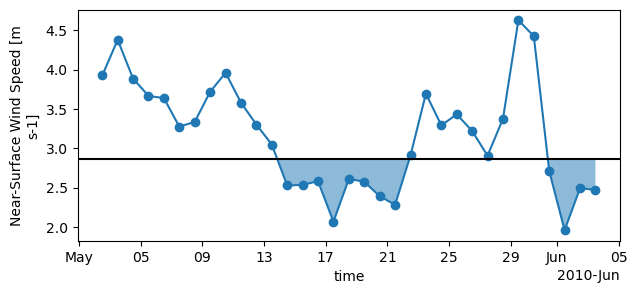

In [265]:
fig, ax = plt.subplots(1,1, figsize=(7,3))
duration, start = top10.iloc[2]
wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 12, 12)
plot_ts(ax, wind_ts, pctl10_obs)

14.080810546875
19.283203125
15.3671875
16.056640625
17.109375
18.6015625
16.31640625
17.939453125
16.908203125
18.587890625
19.173828125


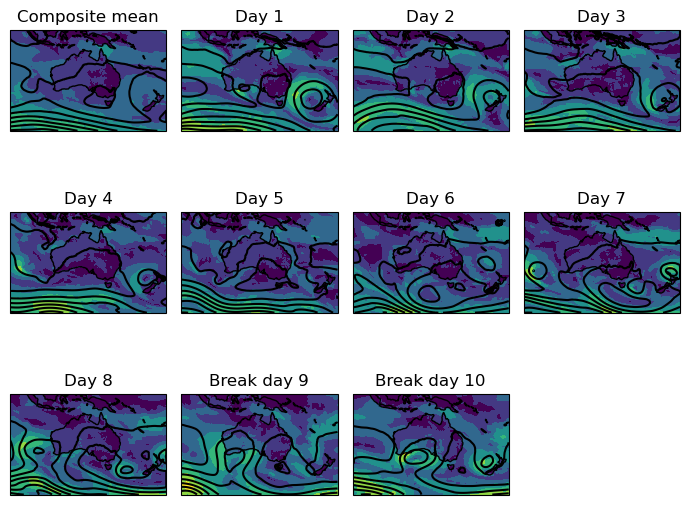

In [266]:
plot_event(2)

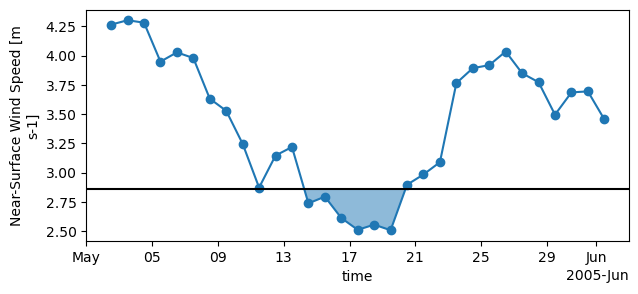

In [267]:
fig, ax = plt.subplots(1,1, figsize=(7,3))
duration, start = top10.iloc[3]
wind_ts = sfcWind_slice(ds_obs["sfcWind"], start, duration, 12, 12)
plot_ts(ax, wind_ts, pctl10_obs)

14.055338541666666
18.5390625
17.5703125
20.708984375
21.2265625
17.193359375
17.400390625
18.115234375
18.62890625


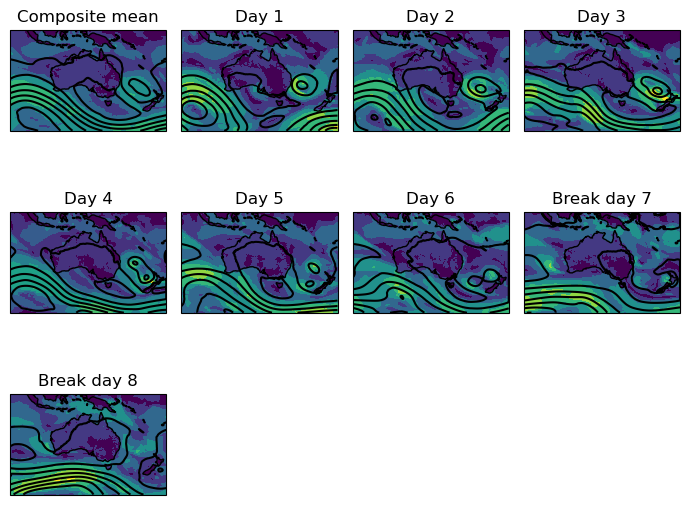

In [268]:
plot_event(3)